# Menentukan Solusi & Pertanyaan Bisnis

**Problem:**

Kesulitan komunikasi antara teman tuli yang menggunakan BISINDO dengan masyarakat umum yang tidak memahami bahasa isyarat.

**Solusi Utama:**

Mengembangkan model pengenalan gambar otomatis (Computer Vision) yang dapat mengklasifikasikan abjad BISINDO untuk membantu proses transliterasi secara real-time berbasis gambar statis.

**Pertanyaan Bisnis:**


1.   Berapa distribusi jumlah sampel gambar per label abjad BISINDO untuk memastikan dataset seimbang (balanced)?
2.   Apakah terdapat data yang rusak atau duplikat yang dapat mengganggu performa model saat training?






## Data Loading

In [1]:
!mkdir -p ~/.kaggle && echo KGAT_a156317fc6f86e944aeaeb8d6096d309 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadfathinraihan/bisindo-dataset")

print("Path to dataset files:", path)

100%|██████████| 7.87G/7.87G [01:15<00:00, 112MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1


In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import pandas as pd
import time

# Define the dataset path
dataset_path = path + '/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images'
print(dataset_path)

/root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images


In [4]:
import os
from PIL import Image, ImageOps

def fix_exif_orientation(dataset_dir):
    print(f"Memulai pemindaian EXIF di folder: {dataset_dir}")
    gambar_diperbaiki = 0
    gambar_error = 0

    # os.walk akan menelusuri folder utama dan semua subfoldernya (A-Z)
    for root, dirs, files in os.walk(dataset_dir):
        for file in files:
            # Hanya proses file gambar
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)

                try:
                    img = Image.open(filepath)
                    img_fixed = ImageOps.exif_transpose(img)

                    if img_fixed != img:
                        img_fixed.save(filepath, quality=100)
                        gambar_diperbaiki += 1

                except Exception as e:
                    gambar_error += 1

    print("\nPembersihan EXIF Selesai!")
    print(f"Total gambar yang berhasil diperbaiki: {gambar_diperbaiki}")
    print(f"Total error: {gambar_error}")

fix_exif_orientation(dataset_path)

Memulai pemindaian EXIF di folder: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images

Pembersihan EXIF Selesai!
Total gambar yang berhasil diperbaiki: 4466
Total error: 297


### Distribusi Jumlah Sampel Gambar per Label Abjad

Distribution of images per label:
   Label  Count
1      B    185
9      J    185
7      H    184
3      D    184
5      F    184
4      E    184
8      I    184
6      G    184
12     M    184
10     K    184
25     Z    184
24     Y    184
13     N    184
14     O    184
16     Q    184
15     P    184
19     T    184
18     S    184
20     U    184
23     X    184
11     L    183
2      C    183
21     V    182
17     R    182
0      A    181
22     W    180


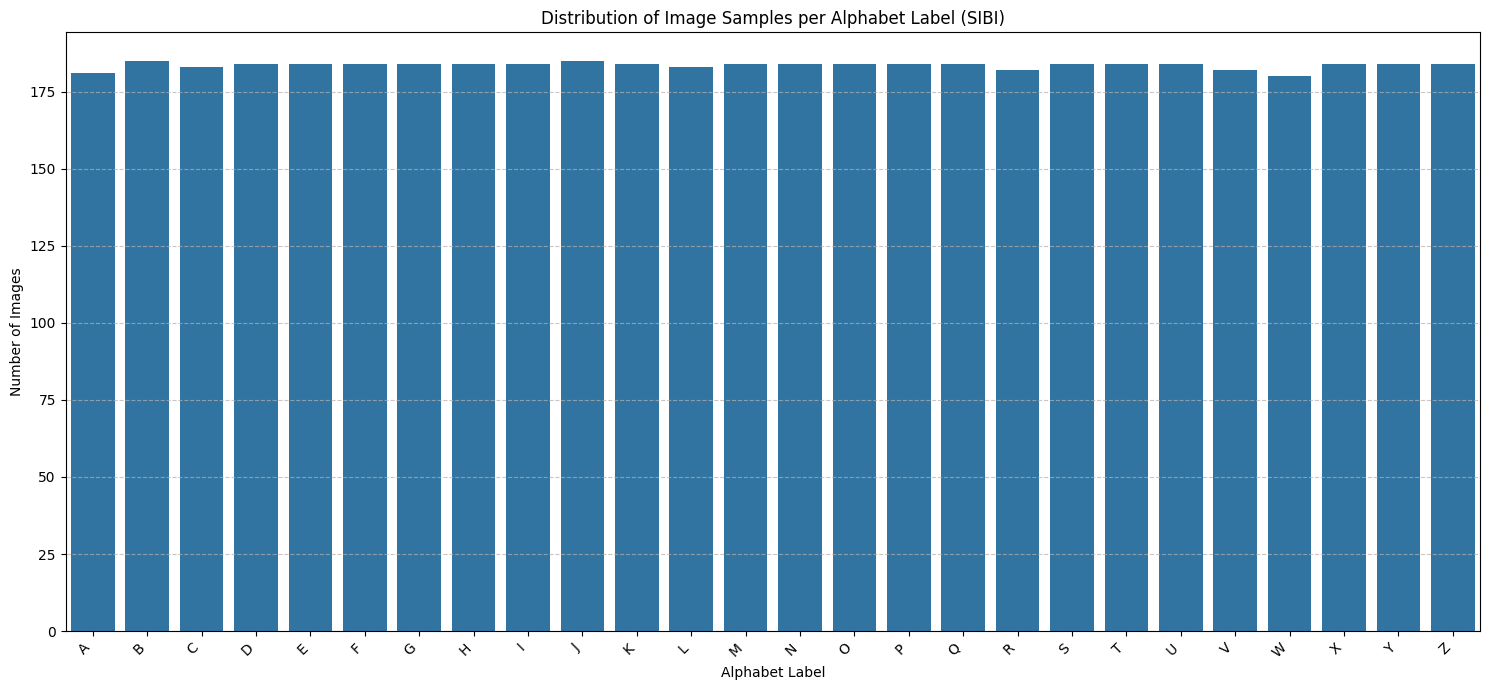

In [5]:
# Get list of all labels (subdirectories)
labels = sorted(os.listdir(dataset_path))

# Count images per label
label_counts = {}
for label in labels:
    label_dir = os.path.join(dataset_path, label)
    if os.path.isdir(label_dir):
        # Assuming all files in these directories are images
        label_counts[label] = len(os.listdir(label_dir))

# Convert to DataFrame
import pandas as pd
df_counts = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])

# Display counts
print("Distribution of images per label:")
print(df_counts.sort_values(by='Count', ascending=False))

# Plot the distribution
plt.figure(figsize=(15, 7))
sns.barplot(x='Label', y='Count', data=df_counts)
plt.title('Distribution of Image Samples per Alphabet Label (SIBI)')
plt.xlabel('Alphabet Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pemeriksaan Integritas Gambar

In [6]:
corrupted_files = []
accessible_files = []

for label in labels:
    label_dir = os.path.join(dataset_path, label)
    if os.path.isdir(label_dir):
        image_files = [f for f in os.listdir(label_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for image_name in image_files:
            image_path = os.path.join(label_dir, image_name)
            try:
                with Image.open(image_path) as img:
                    img.verify()
                accessible_files.append(image_path)
            except (IOError, SyntaxError) as e:
                corrupted_files.append((image_path, str(e)))

print("\n--- Hasil Pemeriksaan Gambar ---")
print(f"Total file yang diperiksa: {len(accessible_files) + len(corrupted_files)}")
print(f"File yang dapat diakses: {len(accessible_files)}")
print(f"File yang rusak atau tidak dapat diakses: {len(corrupted_files)}")

if corrupted_files:
    print(f"\n{len(corrupted_files)} file yang rusak atau tidak dapat diakses ditemukan.")
else:
    print("\nTidak ada file yang rusak atau tidak dapat diakses ditemukan. Semua gambar dapat diakses.")


--- Hasil Pemeriksaan Gambar ---
Total file yang diperiksa: 4763
File yang dapat diakses: 4466
File yang rusak atau tidak dapat diakses: 297

297 file yang rusak atau tidak dapat diakses ditemukan.


### Pemeriksaan Data Duplikat

Selesai! Ditemukan 2 file duplikat.

--- Visualisasi File Duplikat ---


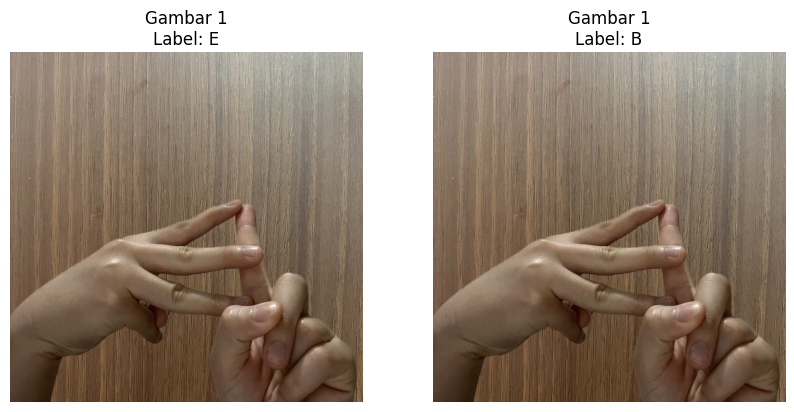

Path 1: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images/E/E_polos gelap_Iphone_13promax.jpg
Path 2: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images/B/B_polos gelap_Iphone_13promax.jpg
--------------------------------------------------


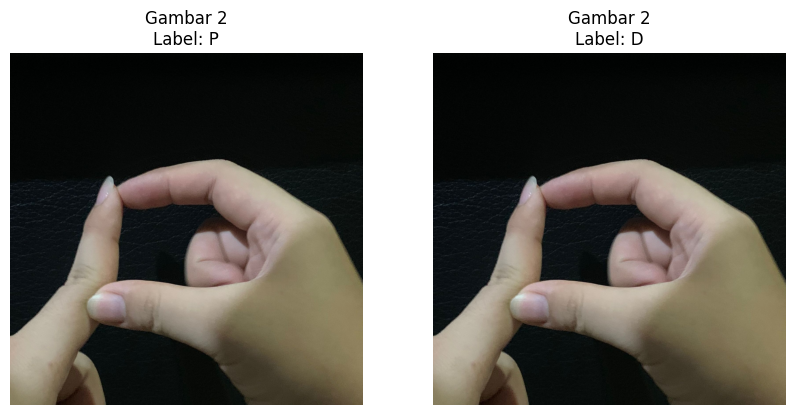

Path 1: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images/P/P_Polos Gelap_iPhone_XR.jpeg
Path 2: /root/.cache/kagglehub/datasets/muhammadfathinraihan/bisindo-dataset/versions/1/BISINDO Indonesian Sign Language Alphabet Image Data/01. Original Images/D/D_Polos Gelap_iPhone_XR.jpeg
--------------------------------------------------


In [7]:
import hashlib
import matplotlib.pyplot as plt
from PIL import Image

def get_hash(fname):
    hash_md5 = hashlib.md5()
    with open(fname, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

# List untuk menampung semua hash yang ditemukan
hashes = {}
duplicates = []

for path in accessible_files:
    file_hash = get_hash(path)

    if file_hash in hashes:
        # Simpan pasangan (file yang baru ditemukan, file yang sudah ada sebelumnya)
        duplicates.append((path, hashes[file_hash]))
    else:
        hashes[file_hash] = path

print(f"Selesai! Ditemukan {len(duplicates)} file duplikat.")

if duplicates:
    print("\n--- Visualisasi File Duplikat ---")
    for i, (dup, original) in enumerate(duplicates):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        img_dup = Image.open(dup)
        axes[0].imshow(img_dup)
        axes[0].set_title(f"Gambar {i+1}\nLabel: {os.path.basename(os.path.dirname(dup))}")
        axes[0].axis('off')

        img_orig = Image.open(original)
        axes[1].imshow(img_orig)
        axes[1].set_title(f"Gambar {i+1}\nLabel: {os.path.basename(os.path.dirname(original))}")
        axes[1].axis('off')

        plt.show()
        print(f"Path 1: {dup}")
        print(f"Path 2: {original}\n" + "-"*50)
else:
    print("Tidak ada file duplikat yang ditemukan.")

## Data Cleaning

### Menghapus File Gambar yang Rusak atau Tidak Dapat Diakses

In [8]:

deleted_count = 0
failed_to_delete = []

print("Menghapus file yang rusak atau tidak dapat diakses...")

for file_path, _ in corrupted_files:
    try:
        if os.path.exists(file_path):
            os.remove(file_path)
            deleted_count += 1
        else:
            print(f"File tidak ditemukan saat mencoba menghapus: {file_path}")
    except OSError as e:
        failed_to_delete.append((file_path, str(e)))
        print(f"Gagal menghapus file {file_path}: {e}")

print("\n--- Hasil Penghapusan File ---")
print(f"Jumlah file yang berhasil dihapus: {deleted_count}")
print(f"Jumlah file yang gagal dihapus: {len(failed_to_delete)}")

if failed_to_delete:
    print("Daftar file yang gagal dihapus (periksa izin atau masalah lain):")
    for path, error in failed_to_delete:
        print(f"- {path}: {error}")
else:
    print("Semua file yang rusak berhasil dihapus.")


Menghapus file yang rusak atau tidak dapat diakses...

--- Hasil Penghapusan File ---
Jumlah file yang berhasil dihapus: 297
Jumlah file yang gagal dihapus: 0
Semua file yang rusak berhasil dihapus.


### Menghapus file duplikat

In [9]:
deleted_duplicates_count = 0
failed_to_delete_duplicates = []

for dup_path, orig_path in duplicates:
    for file_path in [dup_path, orig_path]:
        try:
            if os.path.exists(file_path):
                os.remove(file_path)
                deleted_duplicates_count += 1
            else:
                print(f"File tidak ditemukan: {file_path}")
        except OSError as e:
            failed_to_delete_duplicates.append((file_path, str(e)))
            print(f"Gagal menghapus {file_path}: {e}")

print("\n--- Hasil Penghapusan Duplikat ---")
print(f"Total file berhasil dihapus: {deleted_duplicates_count}")
print(f"Total file gagal dihapus: {len(failed_to_delete_duplicates)}")


--- Hasil Penghapusan Duplikat ---
Total file berhasil dihapus: 4
Total file gagal dihapus: 0


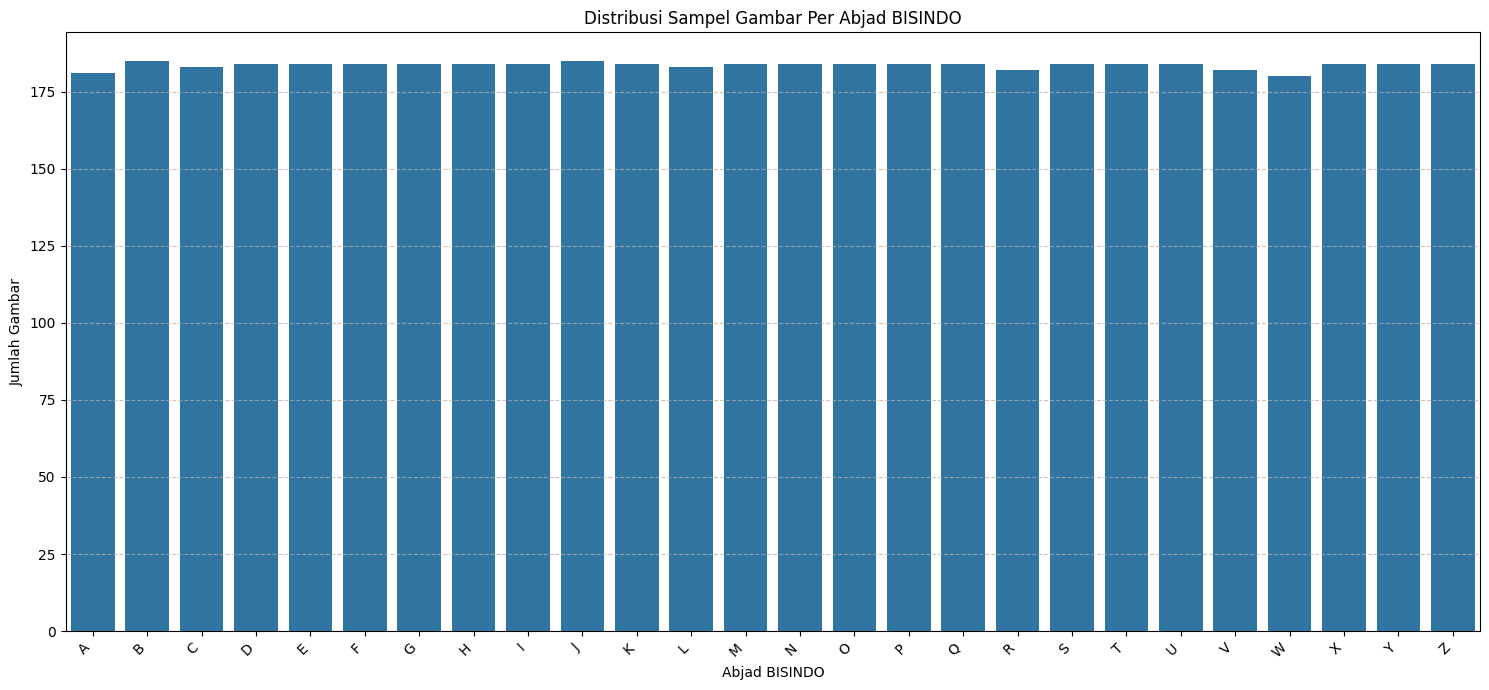

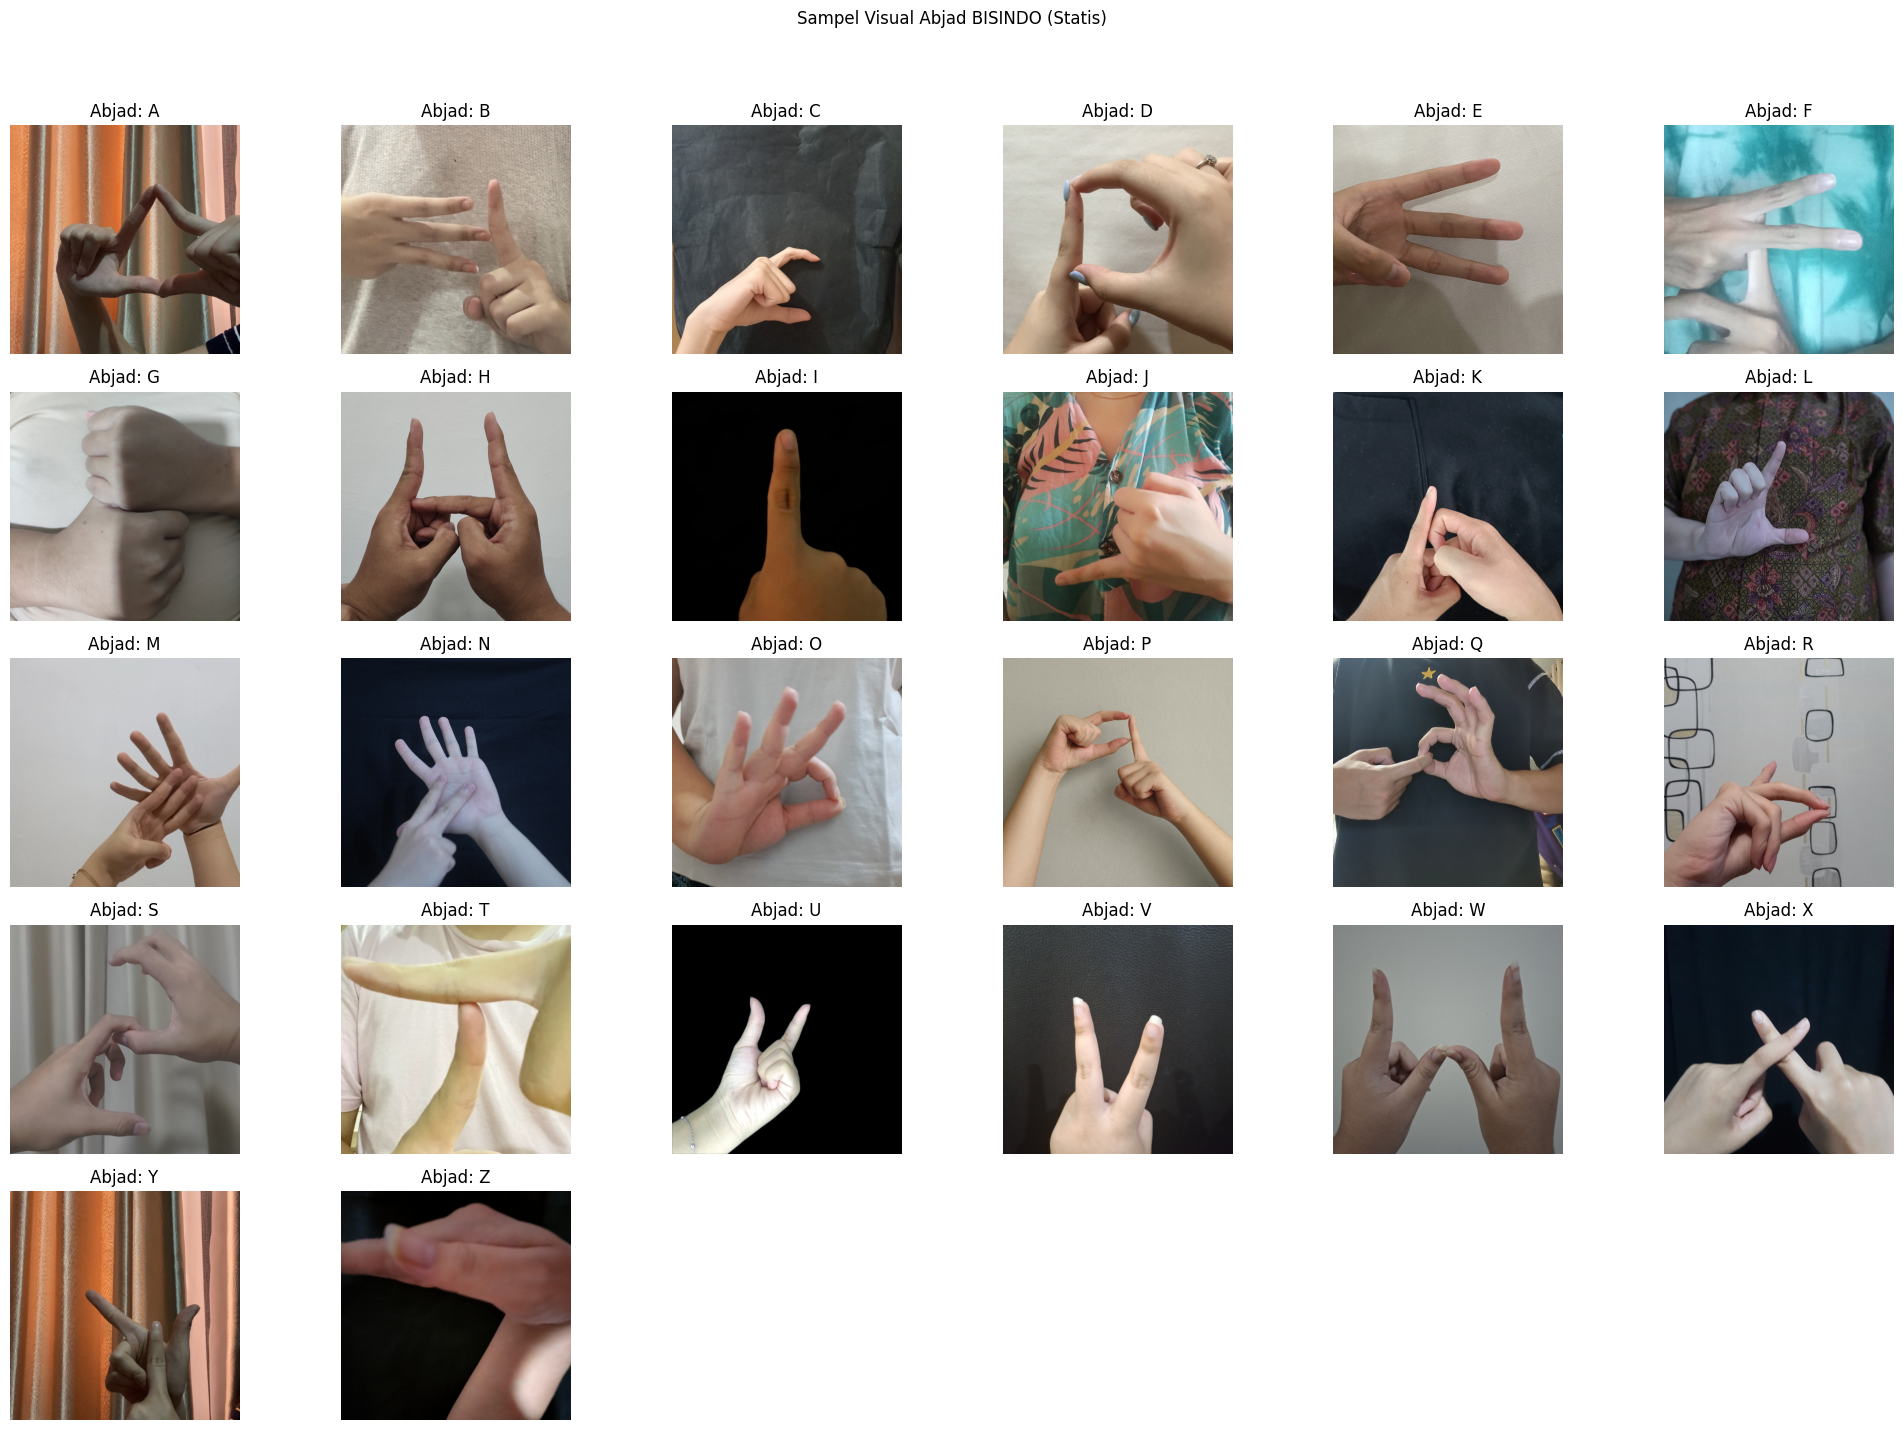

In [10]:

# Pastikan df_counts sudah berisi data dari folder BISINDO
plt.figure(figsize=(15, 7))
sns.barplot(x='Label', y='Count', data=df_counts)
plt.title('Distribusi Sampel Gambar Per Abjad BISINDO')
plt.xlabel('Abjad BISINDO')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Menampilkan sampel gambar BISINDO (Explanatory)
from PIL import Image
import os

plt.figure(figsize=(20, 15))
# Mengambil sampel dari direktori BISINDO yang sudah didefinisikan (dataset_path)
for i, label in enumerate(labels):
    label_dir = os.path.join(dataset_path, label)
    sample_file = os.listdir(label_dir)[0]
    img = Image.open(os.path.join(label_dir, sample_file))

    plt.subplot(5, 6, i+1)
    plt.imshow(img)
    plt.title(f"Abjad: {label}")
    plt.axis('off')

plt.suptitle("Sampel Visual Abjad BISINDO (Statis)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Data Preprocessing

In [11]:
import glob
from tqdm import tqdm

def get_image_absolute_paths(directory_path):
    """
    Retrieves the absolute paths of all images in a directory and its subdirectories.
    """
    # Define common image extensions
    extensions = (
        '*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp', '*.tiff',
        '*.JPG', '*.JPEG', '*.PNG', '*.BMP', '*.WEBP', '*.TIFF'
    )
    image_paths = []

    for ext in tqdm(extensions):
        # Use recursive glob pattern to find files in all subdirectories
        search_pattern = os.path.join(directory_path, '**', ext)

        # recursive=True is necessary to support the '**' wildcard
        found_files = glob.glob(search_pattern, recursive=True)

        # Convert each relative path to an absolute path
        absolute_files = [os.path.abspath(f) for f in found_files]
        image_paths.extend(absolute_files)

    image_paths = list(set(image_paths))

    return image_paths

In [12]:
import pandas as pd
import os

all_image_paths = get_image_absolute_paths(dataset_path)

# Create an initial DataFrame from all image paths
df = pd.DataFrame({
    'file_path': all_image_paths,
    'label': [os.path.basename(os.path.dirname(f)) for f in all_image_paths]
})
print(f"Initial DataFrame created with {len(df)} entries.")

100%|██████████| 12/12 [00:00<00:00, 64.63it/s]

Initial DataFrame created with 4462 entries.


In [13]:
df.head()

,file_path,label
0,/root/.cache/kagglehub/datasets/muhammadfathin...,I
1,/root/.cache/kagglehub/datasets/muhammadfathin...,G
2,/root/.cache/kagglehub/datasets/muhammadfathin...,N
3,/root/.cache/kagglehub/datasets/muhammadfathin...,U
4,/root/.cache/kagglehub/datasets/muhammadfathin...,D


### Split Dataset

In [14]:
from sklearn.model_selection import train_test_split

X = df['file_path']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [15]:
train_df = pd.DataFrame({'file_path': X_train, 'label': y_train})
val_df = pd.DataFrame({'file_path': X_val, 'label': y_val})
test_df = pd.DataFrame({'file_path': X_test, 'label': y_test})

print("panjang train", len(train_df))
print("panjang val", len(val_df))
print("panjang test", len(test_df))

panjang train 2855
panjang val 714
panjang test 893


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Augmentation untuk data train
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2855 validated image filenames belonging to 26 classes.
Found 714 validated image filenames belonging to 26 classes.
Found 893 validated image filenames belonging to 26 classes.


# Persiapan Data untuk Pemodelan (Data Dictionary)

In [17]:
# Membuat Data Dictionary untuk BISINDO
data_dict = {
    'fitur': 'File path gambar abjad BISINDO (Data pixel)',
    'target': 'Abjad BISINDO (A-Z)',
    'karakteristik': 'Gambar statis (tidak memerlukan gerakan)',
    'total_data': len(accessible_files)
}

print("Data Dictionary Terupdate untuk BISINDO:")
for key, value in data_dict.items():
    print(f"- {key}: {value}")

Data Dictionary Terupdate untuk BISINDO:
- fitur: File path gambar abjad BISINDO (Data pixel)
- target: Abjad BISINDO (A-Z)
- karakteristik: Gambar statis (tidak memerlukan gerakan)
- total_data: 4466


In [18]:
# Mengonversi list accessible_files menjadi DataFrame dan menyimpannya ke CSV

# Mengambil label dari nama folder induk setiap file gambar
df = pd.DataFrame({
    'file_path': accessible_files,
    'label': [os.path.basename(os.path.dirname(f)) for f in accessible_files]
})

# Menyimpan ke file CSV yang dicari oleh dashboard Streamlit
df.to_csv('cleaned_data_bisindo.csv', index=False)

print("File 'cleaned_data_bisindo.csv' berhasil dibuat untuk Dashboard!")

File 'cleaned_data_bisindo.csv' berhasil dibuat untuk Dashboard!


In [19]:
import os

# List isi folder dataset
files = os.listdir(dataset_path)
print(f"File/Folder dalam direktori: {files}")

File/Folder dalam direktori: ['V', 'A', 'K', 'H', 'T', 'E', 'S', 'X', 'C', 'W', 'I', 'D', 'Y', 'N', 'M', 'B', 'U', 'R', 'Z', 'Q', 'O', 'J', 'P', 'L', 'G', 'F']


# Dashboard Interaktif (Streamlit)

In [20]:
%%writefile app.py
import streamlit as st  # BARIS INI HARUS ADA PALING ATAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Konfigurasi Halaman
st.set_page_config(page_title="Dashboard BISINDO", layout="wide")
st.title("📊 Dashboard Analisis Dataset BISINDO")
st.markdown("---")

# 2. Load Data
@st.cache_data
def load_data():
    # Pastikan file csv ini sudah dibuat di cell sebelumnya
    return pd.read_csv('cleaned_data_bisindo.csv')

try:
    df = load_data()

    # 3. Sidebar (Ringkasan Dataset) - Versi stabil tanpa st.metric
    st.sidebar.header("Ringkasan Dataset")
    st.sidebar.write(f"**Total Gambar:** {len(df)}")
    st.sidebar.write(f"**Jumlah Label:** {df['label'].nunique()}")

    # 4. Visualisasi Distribusi
    st.subheader("1. Distribusi Sampel Per Abjad BISINDO")
    st.write("Wawasan: Dataset BISINDO ini menggunakan gambar statis untuk setiap abjad (A-Z).")

    fig, ax = plt.subplots(figsize=(12, 5))
    order = sorted(df['label'].unique())
    sns.countplot(data=df, x='label', order=order, palette='viridis', ax=ax)
    plt.xlabel("Abjad BISINDO")
    plt.ylabel("Jumlah Gambar")
    st.pyplot(fig)

    # 5. Kesimpulan
    st.markdown("---")
    st.subheader("📌 Kesimpulan Proyek")
    st.success("""
    - **Dataset:** Menggunakan BISINDO (Bahasa Isyarat Indonesia).
    - **Karakteristik:** Data berupa gambar statis, tidak memerlukan ekstraksi frame video.
    - **Kesiapan Model:** Distribusi data sudah seimbang dan siap masuk ke tahap pelatihan CNN.
    """)

except FileNotFoundError:
    st.error("File 'cleaned_data_bisindo.csv' tidak ditemukan. Harap jalankan cell 'Data Wrangling' terlebih dahulu.")

Writing app.py


In [21]:
# Hapus proses lama jika ada
!pkill streamlit
!pkill cloudflared

# Instalasi paket jika belum (opsional jika sudah di awal)
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.9 MB/s eta 0:00:00


In [22]:
# Update library (untuk memastikan module JavaScript terbaru tersedia)
!pip install -U streamlit -q

In [23]:
# Jalankan streamlit tanpa memblokir cell
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [ ]:
# Beri waktu streamlit untuk booting
time.sleep(15)

# Jalankan tunnel untuk mendapatkan link publik
!npx cloudflared tunnel --url http://127.0.0.1:8501

⠙⠹⠸⠼⠴⠦Need to install the following packages:
cloudflared@0.7.1
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦2026-06-04T11:22:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-04T11:22:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-04T11:22:31Z INF +--------------------------------------------------------------------------------------------+
2026-06-04T11:22:31Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time 